<a href="https://colab.research.google.com/github/Udison81/Udison81.github.io/blob/main/Projeto_queimadas_vulnerabilidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise da Relação entre Vulnerabilidade Econômica e Queimadas no Brasil

---

## Informações do Projeto

| Item | Descrição |
|------|-----------|
| **Título** | Análise da Relação entre Vulnerabilidade Econômica e Queimadas no Brasil |
| **Temática** | Análise de dados ambientais e socioeconômicos |
| **Hipótese** | Existe uma relação direta entre o nível de vulnerabilidade econômica e o número de queimadas nas regiões do Brasil |

---

## Bases de Dados Utilizadas (3 bases)

| Base | Fonte | Formato |
|------|-------|---------|  
| **PIB Municipal** | basedosdados.org | CSV |
| **Queimadas** | basedosdados.org | CSV |
| **INPE Desmatamento** | TerraBrasilis/INPE | CSV |
---

## 1. Preparação do Ambiente

In [ ]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Configurações do Pandas
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Ambiente carregado com sucesso!")

Ambiente carregado com sucesso!


## 2. Upload e Carregamento dos Dados

In [16]:
# Upload dos arquivos no Google Colab
from google.colab import files

print("Faça o upload dos 3 arquivos CSV:")
print("   1. base-dos-dados-pib.csv")
print("   2. base-dos-dados-queimada.csv")
print("   3. inpe-queimadas-desmatamento.csv")
print()

uploaded = files.upload()

Faça o upload dos 3 arquivos CSV:
   1. base-dos-dados-pib.csv
   2. base-dos-dados-queimada.csv
   3. inpe-queimadas-desmatamento.csv



Saving inpe-queimadas-desmatamento.csv to inpe-queimadas-desmatamento.csv
Saving base-dos-dados-queimada.csv to base-dos-dados-queimada.csv
Saving base-dos-dados-pib.csv to base-dos-dados-pib.csv


In [21]:
# Carregamento das bases com Pandas
print("Carregando as bases de dados...")
print("="*50)

# Base 1: PIB Municipal
df_pib = pd.read_csv('base-dos-dados-pib.csv')
print(f"\nBase 1 - PIB: {df_pib.shape[0]:,} linhas, {df_pib.shape[1]} colunas")

# Base 2: Queimadas
df_queimadas = pd.read_csv('base-dos-dados-queimada.csv')
print(f"Base 2 - Queimadas: {df_queimadas.shape[0]:,} linhas, {df_queimadas.shape[1]} colunas")

# Base 3: INPE (separador ;)
df_inpe = pd.read_csv('inpe-queimadas-desmatamento.csv', sep=';')
print(f"Base 3 - INPE: {df_inpe.shape[0]:,} linhas, {df_inpe.shape[1]} colunas")

print("\nTodas as bases carregadas!")

Carregando as bases de dados...

Base 1 - PIB: 111,400 linhas, 9 colunas
Base 2 - Queimadas: 406,878 linhas, 10 colunas
Base 3 - INPE: 10,197 linhas, 4 colunas

Todas as bases carregadas!


## 3. Exploração Inicial dos Dados

### 3.1 Base de PIB Municipal

In [22]:
# Visualizar primeiras linhas
print("📊 BASE 1: PIB MUNICIPAL")
print("="*50)
df_pib.head()

📊 BASE 1: PIB MUNICIPAL


,id_municipio,ano,pib,impostos_liquidos,va,va_agropecuaria,va_industria,va_servicos,va_adespss
0,1200500,2002,125410.0,2474.0,122936.0,42357.0,8335.0,20708.0,51537.0
1,1300300,2002,76039.0,1632.0,74407.0,34073.0,3678.0,8944.0,27712.0
2,1302108,2002,13798.0,324.0,13474.0,1568.0,388.0,1203.0,10315.0
3,1400175,2002,38787.0,918.0,37868.0,4671.0,2536.0,4567.0,26095.0
4,1502400,2002,498849.0,58905.0,439944.0,18100.0,80539.0,239642.0,101663.0


In [23]:
# Estrutura do dataset
df_pib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111400 entries, 0 to 111399
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id_municipio       111400 non-null  int64  
 1   ano                111400 non-null  int64  
 2   pib                111326 non-null  float64
 3   impostos_liquidos  111326 non-null  float64
 4   va                 111326 non-null  float64
 5   va_agropecuaria    111326 non-null  float64
 6   va_industria       111326 non-null  float64
 7   va_servicos        111326 non-null  float64
 8   va_adespss         111326 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 7.6 MB


In [25]:
# Estatísticas descritivas
df_pib.describe()

,id_municipio,ano,pib,impostos_liquidos,va,va_agropecuaria,va_industria,va_servicos,va_adespss
count,1.114000e+05,111400.000000,1.113260e+05,1.113260e+05,1.113260e+05,1.113260e+05,1.113260e+05,1.113260e+05,1.113260e+05
mean,3.253591e+06,2011.500000,8.350322e+05,1.194854e+05,7.155468e+05,4.016658e+04,1.738817e+05,3.817421e+05,1.197564e+05
std,9.848263e+05,5.766307,8.969523e+06,1.646871e+06,7.356378e+06,9.218991e+04,1.208267e+06,5.492217e+06,1.213120e+06
min,1.100015e+06,2002.000000,-1.904600e+04,-1.508800e+04,-5.105930e+05,-2.299000e+03,-2.897193e+06,3.720000e+02,1.447000e+03
25%,2.512101e+06,2006.750000,4.408275e+04,1.703000e+03,4.201100e+04,6.707250e+03,2.182000e+03,1.005800e+04,1.456100e+04
50%,3.146280e+06,2011.500000,1.037725e+05,5.309000e+03,9.778250e+04,1.691200e+04,7.300000e+03,2.750000e+04,2.945700e+04
75%,4.119202e+06,2016.250000,2.984675e+05,2.163075e+04,2.754560e+05,4.057250e+04,4.084450e+04,9.433950e+04,6.853075e+04
max,5.300108e+06,2021.000000,8.289806e+08,1.681840e+08,6.607966e+08,5.004239e+06,6.689305e+07,5.497674e+08,1.168092e+08


In [26]:
# Verificar valores nulos
print("Valores nulos por coluna:")
df_pib.isnull().sum()

Valores nulos por coluna:


,0
id_municipio,0
ano,0
pib,74
impostos_liquidos,74
va,74
va_agropecuaria,74
va_industria,74
va_servicos,74
va_adespss,74


### 3.2 Base de Queimadas

In [27]:
# Visualizar primeiras linhas
print("BASE 2: QUEIMADAS")
print("="*50)
df_queimadas.head()

BASE 2: QUEIMADAS


,ano,bioma,data_hora,dias_sem_chuva,id_municipio,latitude,longitude,mes,satelite,sigla_uf
0,2020,Cerrado,2020-01-01 16:45:00,NaN,3119302,-18.137,-47.179,1,NaN,MG
1,2020,Mata Atlântica,2020-01-01 16:45:00,NaN,3302700,-22.950,-42.912,1,NaN,RJ
2,2020,Mata Atlântica,2020-01-01 16:45:00,NaN,3302700,-22.959,-42.925,1,NaN,RJ
3,2020,Mata Atlântica,2020-01-01 16:45:00,NaN,3302700,-22.957,-42.915,1,NaN,RJ
4,2020,Mata Atlântica,2020-01-01 16:45:00,NaN,3302700,-22.952,-42.922,1,NaN,RJ


In [29]:
# Estrutura do dataset
df_queimadas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406878 entries, 0 to 406877
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ano             406878 non-null  int64  
 1   bioma           406878 non-null  object 
 2   data_hora       406878 non-null  object 
 3   dias_sem_chuva  0 non-null       float64
 4   id_municipio    406878 non-null  int64  
 5   latitude        406878 non-null  float64
 6   longitude       406878 non-null  float64
 7   mes             406878 non-null  int64  
 8   satelite        0 non-null       float64
 9   sigla_uf        406878 non-null  object 
dtypes: float64(4), int64(3), object(3)
memory usage: 31.0+ MB


In [30]:
# Contagem por bioma
print("Focos por Bioma:")
df_queimadas['bioma'].value_counts()

Focos por Bioma:


,count
bioma,
Amazônia,178251
Cerrado,126547
Mata Atlântica,36344
Caatinga,32421
Pantanal,30374
Pampa,2941


In [31]:
# Contagem por estado
print("Focos por Estado (UF):")
df_queimadas['sigla_uf'].value_counts()

Focos por Estado (UF):


,count
sigla_uf,
MT,70228
PA,61479
MA,32894
AM,31577
BA,22271
TO,22100
PI,22062
MS,21457
RO,21175


### 3.3 Base INPE

In [33]:
# Visualizar primeiras linhas
print("BASE 3: INPE")
print("="*50)
df_inpe.head(10)

BASE 3: INPE


,date,class,focuses,uf
0,2026/01,Fogo em áreas de desmatamento consolidado,8,RIO GRANDE DO SUL
1,2026/01,Fogo em áreas de desmatamento recente,1,RIO GRANDE DO SUL
2,2026/01,Fogo em áreas de vegetação nativa,1,RIO GRANDE DO SUL
3,2025/01,Fogo em áreas de desmatamento consolidado,31,RIO GRANDE DO SUL
4,2025/01,Fogo em áreas de desmatamento recente,11,RIO GRANDE DO SUL
5,2025/01,Fogo em áreas de vegetação nativa,11,RIO GRANDE DO SUL
6,2025/02,Fogo em áreas de desmatamento consolidado,29,RIO GRANDE DO SUL
7,2025/02,Fogo em áreas de desmatamento recente,3,RIO GRANDE DO SUL
8,2025/02,Fogo em áreas de vegetação nativa,17,RIO GRANDE DO SUL
9,2025/03,Fogo em áreas de desmatamento consolidado,38,RIO GRANDE DO SUL


In [35]:
# Estrutura
df_inpe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10197 entries, 0 to 10196
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   date     10197 non-null  object
 1   class    10197 non-null  object
 2   focuses  10197 non-null  int64 
 3   uf       10197 non-null  object
dtypes: int64(1), object(3)
memory usage: 318.8+ KB


## 4. Tratamento e Limpeza dos Dados

### 4.1 Dicionários de Mapeamento

In [36]:
# Mapeamento de UF para Região
uf_para_regiao = {
    # Norte
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte',
    'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    # Nordeste
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste',
    'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    # Centro-Oeste
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'MT': 'Centro-Oeste',
    # Sudeste
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    # Sul
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

# Mapeamento de nome do estado para sigla
estado_para_sigla = {
    'ACRE': 'AC', 'ALAGOAS': 'AL', 'AMAPÁ': 'AP', 'AMAZONAS': 'AM',
    'BAHIA': 'BA', 'CEARÁ': 'CE', 'DISTRITO FEDERAL': 'DF', 'ESPÍRITO SANTO': 'ES',
    'GOIÁS': 'GO', 'MARANHÃO': 'MA', 'MATO GROSSO': 'MT', 'MATO GROSSO DO SUL': 'MS',
    'MINAS GERAIS': 'MG', 'PARÁ': 'PA', 'PARAÍBA': 'PB', 'PARANÁ': 'PR',
    'PERNAMBUCO': 'PE', 'PIAUÍ': 'PI', 'RIO DE JANEIRO': 'RJ', 'RIO GRANDE DO NORTE': 'RN',
    'RIO GRANDE DO SUL': 'RS', 'RONDÔNIA': 'RO', 'RORAIMA': 'RR', 'SANTA CATARINA': 'SC',
    'SÃO PAULO': 'SP', 'SERGIPE': 'SE', 'TOCANTINS': 'TO'
}

# Mapeamento código IBGE para UF
cod_ibge_para_uf = {
    '11': 'RO', '12': 'AC', '13': 'AM', '14': 'RR', '15': 'PA', '16': 'AP', '17': 'TO',
    '21': 'MA', '22': 'PI', '23': 'CE', '24': 'RN', '25': 'PB', '26': 'PE', '27': 'AL',
    '28': 'SE', '29': 'BA', '31': 'MG', '32': 'ES', '33': 'RJ', '35': 'SP',
    '41': 'PR', '42': 'SC', '43': 'RS', '50': 'MS', '51': 'MT', '52': 'GO', '53': 'DF'
}

print("✅ Dicionários de mapeamento criados!")

✅ Dicionários de mapeamento criados!


### 4.2 Tratamento do PIB

In [37]:
# Criar cópia
df_pib_clean = df_pib.copy()

# Converter id_municipio para string
df_pib_clean['id_municipio'] = df_pib_clean['id_municipio'].astype(str)

# Extrair código UF (2 primeiros dígitos)
df_pib_clean['cod_uf'] = df_pib_clean['id_municipio'].str[:2]

# Mapear para sigla UF
df_pib_clean['sigla_uf'] = df_pib_clean['cod_uf'].map(cod_ibge_para_uf)

# Mapear para região
df_pib_clean['regiao'] = df_pib_clean['sigla_uf'].map(uf_para_regiao)

# Remover linhas com PIB nulo
df_pib_clean = df_pib_clean.dropna(subset=['pib'])

# FILTRAR APENAS ANOS 2020 E 2021, CONFORME SOLICITADO
df_pib_clean = df_pib_clean[df_pib_clean['ano'].isin([2020, 2021])]

# Criar coluna PIB em milhões usando NumPy
df_pib_clean['pib_milhoes'] = np.round(df_pib_clean['pib'] / 1000000, 2)

print(f"PIB tratado e filtrado para 2020-2021: {len(df_pib_clean):,} registros")
df_pib_clean.head()

PIB tratado e filtrado para 2020-2021: 11,140 registros


,id_municipio,ano,pib,impostos_liquidos,va,va_agropecuaria,va_industria,va_servicos,va_adespss,cod_uf,sigla_uf,regiao,pib_milhoes
100260,1100098,2020,666321.0,58284.0,608036.0,137802.0,54519.0,213565.0,202151.0,11,RO,Norte,0.67
100261,1302405,2020,556267.0,22552.0,533715.0,209309.0,24568.0,96813.0,203024.0,13,AM,Norte,0.56
100262,1400159,2020,416440.0,6828.0,409612.0,195775.0,23226.0,51716.0,138895.0,14,RR,Norte,0.42
100263,1705508,2020,787269.0,84884.0,702385.0,37072.0,52905.0,367627.0,244781.0,17,TO,Norte,0.79
100264,2101103,2020,84159.0,3697.0,80463.0,12129.0,3033.0,20882.0,44418.0,21,MA,Nordeste,0.08


### 4.3 Tratamento das Queimadas

In [39]:
# Criar cópia
df_queimadas_clean = df_queimadas.copy()

# Converter data_hora para datetime
df_queimadas_clean['data_hora'] = pd.to_datetime(df_queimadas_clean['data_hora'], format='mixed')

# Extrair mês e criar período seco/chuvoso
df_queimadas_clean['mes_nome'] = df_queimadas_clean['data_hora'].dt.month_name()

# Mapear para região
df_queimadas_clean['regiao'] = df_queimadas_clean['sigla_uf'].map(uf_para_regiao)

# Criar flag período seco (maio a outubro) usando NumPy
df_queimadas_clean['periodo_seco'] = np.where(
    df_queimadas_clean['mes'].isin([5, 6, 7, 8, 9, 10]),
    'Seco', 'Chuvoso'
)

print(f"✅ Queimadas tratadas: {len(df_queimadas_clean):,} registros")
df_queimadas_clean.head()

✅ Queimadas tratadas: 406,878 registros


,ano,bioma,data_hora,dias_sem_chuva,id_municipio,latitude,longitude,mes,satelite,sigla_uf,mes_nome,regiao,periodo_seco
0,2020,Cerrado,2020-01-01 16:45:00,NaN,3119302,-18.137,-47.179,1,NaN,MG,January,Sudeste,Chuvoso
1,2020,Mata Atlântica,2020-01-01 16:45:00,NaN,3302700,-22.950,-42.912,1,NaN,RJ,January,Sudeste,Chuvoso
2,2020,Mata Atlântica,2020-01-01 16:45:00,NaN,3302700,-22.959,-42.925,1,NaN,RJ,January,Sudeste,Chuvoso
3,2020,Mata Atlântica,2020-01-01 16:45:00,NaN,3302700,-22.957,-42.915,1,NaN,RJ,January,Sudeste,Chuvoso
4,2020,Mata Atlântica,2020-01-01 16:45:00,NaN,3302700,-22.952,-42.922,1,NaN,RJ,January,Sudeste,Chuvoso


### 4.4 Tratamento INPE

In [40]:
# Criar cópia e renomear colunas
df_inpe_clean = df_inpe.copy()
df_inpe_clean.columns = ['data', 'classe', 'focos', 'estado']

# Extrair ano e mês
df_inpe_clean['ano'] = df_inpe_clean['data'].str.split('/').str[0].astype(int)
df_inpe_clean['mes'] = df_inpe_clean['data'].str.split('/').str[1].astype(int)

# Mapear estado para sigla
df_inpe_clean['sigla_uf'] = df_inpe_clean['estado'].map(estado_para_sigla)

# Mapear para região
df_inpe_clean['regiao'] = df_inpe_clean['sigla_uf'].map(uf_para_regiao)

print(f"✅ INPE tratado: {len(df_inpe_clean):,} registros")
df_inpe_clean.head()

✅ INPE tratado: 10,197 registros


,data,classe,focos,estado,ano,mes,sigla_uf,regiao
0,2026/01,Fogo em áreas de desmatamento consolidado,8,RIO GRANDE DO SUL,2026,1,RS,Sul
1,2026/01,Fogo em áreas de desmatamento recente,1,RIO GRANDE DO SUL,2026,1,RS,Sul
2,2026/01,Fogo em áreas de vegetação nativa,1,RIO GRANDE DO SUL,2026,1,RS,Sul
3,2025/01,Fogo em áreas de desmatamento consolidado,31,RIO GRANDE DO SUL,2025,1,RS,Sul
4,2025/01,Fogo em áreas de desmatamento recente,11,RIO GRANDE DO SUL,2025,1,RS,Sul


## 5. Análise com Groupby e Agregações

### 5.1 PIB Total por Região e Ano

In [41]:
# Groupby: PIB por região e ano
pib_regiao = df_pib_clean.groupby(['regiao', 'ano']).agg({
    'pib': 'sum',
    'id_municipio': 'count'
}).reset_index()

pib_regiao.columns = ['regiao', 'ano', 'pib_total', 'num_municipios']

# Calcular PIB médio por município
pib_regiao['pib_medio'] = pib_regiao['pib_total'] / pib_regiao['num_municipios']

print("PIB agregado por Região e Ano:")
pib_regiao.head(15)

PIB agregado por Região e Ano:


,regiao,ano,pib_total,num_municipios,pib_medio
0,Centro-Oeste,2020,7.912507e+08,467,1.694327e+06
1,Centro-Oeste,2021,9.321656e+08,467,1.996072e+06
2,Nordeste,2020,1.079331e+09,1794,6.016338e+05
3,Nordeste,2021,1.243103e+09,1794,6.929227e+05
4,Norte,2020,4.781730e+08,450,1.062607e+06
5,Norte,2021,5.640637e+08,450,1.253475e+06
6,Sudeste,2020,3.952695e+09,1668,2.369721e+06
7,Sudeste,2021,4.712982e+09,1668,2.825529e+06
8,Sul,2020,1.308147e+09,1191,1.098361e+06
9,Sul,2021,1.559828e+09,1191,1.309679e+06


### 5.2 Focos de Queimadas por Região e Ano

In [42]:
# Groupby: Contar focos por região e ano
queimadas_regiao = df_queimadas_clean.groupby(['regiao', 'ano']).agg({
    'id_municipio': 'count',
    'dias_sem_chuva': 'mean'
}).reset_index()

queimadas_regiao.columns = ['regiao', 'ano', 'num_focos', 'media_dias_sem_chuva']

print("Queimadas agregadas por Região e Ano:")
queimadas_regiao

Queimadas agregadas por Região e Ano:


,regiao,ano,num_focos,media_dias_sem_chuva
0,Centro-Oeste,2020,65992,NaN
1,Centro-Oeste,2021,38176,NaN
2,Nordeste,2020,40852,NaN
3,Nordeste,2021,50527,NaN
4,Norte,2020,90443,NaN
5,Norte,2021,68254,NaN
6,Sudeste,2020,15954,NaN
7,Sudeste,2021,18630,NaN
8,Sul,2020,9556,NaN
9,Sul,2021,8494,NaN


### 5.3 Focos INPE por Região e Ano

In [43]:
# Groupby: Somar focos INPE por região e ano
inpe_regiao = df_inpe_clean.groupby(['regiao', 'ano'])['focos'].sum().reset_index()
inpe_regiao.columns = ['regiao', 'ano', 'focos_inpe']

print("INPE agregado por Região e Ano:")
inpe_regiao.head(15)

INPE agregado por Região e Ano:


,regiao,ano,focos_inpe
0,Centro-Oeste,2018,15410
1,Centro-Oeste,2019,50193
2,Centro-Oeste,2020,65986
3,Centro-Oeste,2021,38171
4,Centro-Oeste,2022,36453
5,Centro-Oeste,2023,29499
6,Centro-Oeste,2024,70299
7,Centro-Oeste,2025,17989
8,Centro-Oeste,2026,151
9,Nordeste,2018,27578


## 6. Junção das Bases (Merge)

In [44]:
# Encontrar anos em comum
anos_pib = set(pib_regiao['ano'].unique())
anos_queimadas = set(queimadas_regiao['ano'].unique())
anos_comuns = anos_pib.intersection(anos_queimadas)

print(f"Anos no PIB: {sorted(anos_pib)}")
print(f"Anos nas Queimadas: {sorted(anos_queimadas)}")
print(f"Anos em comum: {sorted(anos_comuns)}")

Anos no PIB: [np.int64(2020), np.int64(2021)]
Anos nas Queimadas: [np.int64(2020), np.int64(2021)]
Anos em comum: [np.int64(2020), np.int64(2021)]


In [45]:
# Filtrar para anos em comum
pib_filtrado = pib_regiao[pib_regiao['ano'].isin(anos_comuns)]
queimadas_filtrado = queimadas_regiao[queimadas_regiao['ano'].isin(anos_comuns)]

# Merge das bases
df_analise = pd.merge(pib_filtrado, queimadas_filtrado, on=['regiao', 'ano'], how='outer')

# Preencher valores nulos com 0
df_analise['num_focos'] = df_analise['num_focos'].fillna(0)

df_analise.head(20)

,regiao,ano,pib_total,num_municipios,pib_medio,num_focos,media_dias_sem_chuva
0,Centro-Oeste,2020,7.912507e+08,467,1.694327e+06,65992,NaN
1,Centro-Oeste,2021,9.321656e+08,467,1.996072e+06,38176,NaN
2,Nordeste,2020,1.079331e+09,1794,6.016338e+05,40852,NaN
3,Nordeste,2021,1.243103e+09,1794,6.929227e+05,50527,NaN
4,Norte,2020,4.781730e+08,450,1.062607e+06,90443,NaN
5,Norte,2021,5.640637e+08,450,1.253475e+06,68254,NaN
6,Sudeste,2020,3.952695e+09,1668,2.369721e+06,15954,NaN
7,Sudeste,2021,4.712982e+09,1668,2.825529e+06,18630,NaN
8,Sul,2020,1.308147e+09,1191,1.098361e+06,9556,NaN
9,Sul,2021,1.559828e+09,1191,1.309679e+06,8494,NaN


## 8. Visualização dos Dados (Gráficos)

### Gráfico 1: Pib Total por Região (Barra)

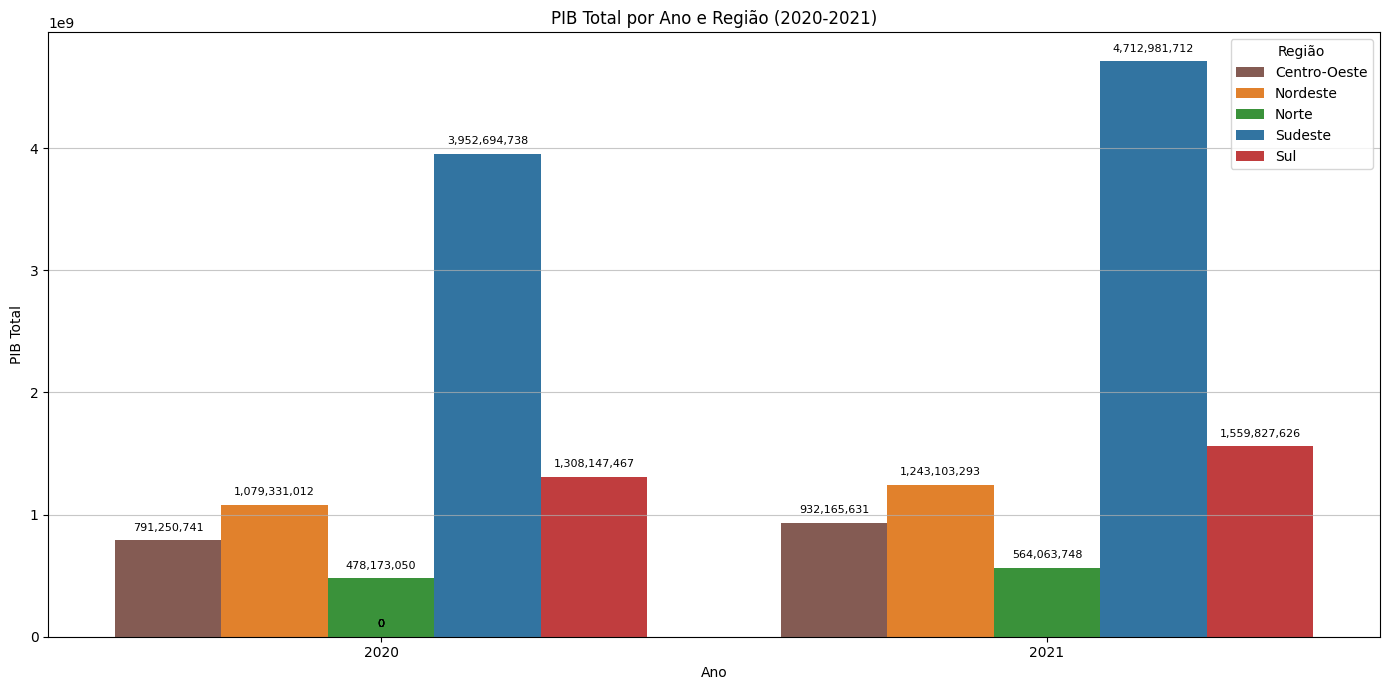


INTERPRETAÇÃO: Este gráfico de barras exibe o PIB Total para cada região nos anos de 2020 e 2021. Permite uma comparação direta da performance econômica entre as regiões nesse período específico.


In [46]:
plt.figure(figsize=(14, 7))

# Filtrar pib_regiao para os anos 2020 e 2021
pib_regiao_filtered = pib_regiao[pib_regiao['ano'].isin([2020, 2021])]

sns.barplot(x='ano', y='pib_total', hue='regiao', data=pib_regiao_filtered, palette=GLOBAL_REGION_COLORS)

# Adicionar valores nas barras
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,.0f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 9),
                       textcoords='offset points',
                       fontsize=8, color='black')

plt.xlabel('Ano')
plt.ylabel('PIB Total')
plt.title('PIB Total por Ano e Região (2020-2021)')
plt.legend(title='Região')
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.savefig('grafico_pib_total_por_ano_regiao_2020_2021.png', dpi=150)
plt.show()

print("\nINTERPRETAÇÃO: Este gráfico de barras exibe o PIB Total para cada região nos anos de 2020 e 2021. Permite uma comparação direta da performance econômica entre as regiões nesse período específico.")

### Gráfico 2: Total de Focos de queimadas por Região (Barra)

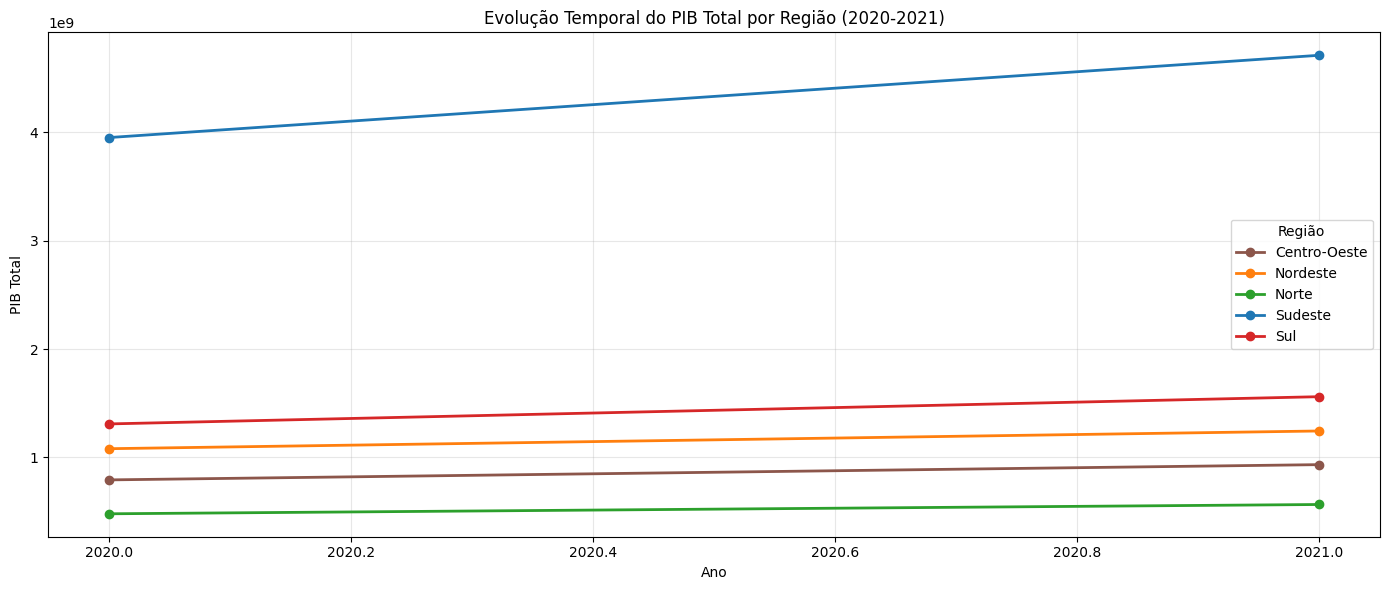


INTERPRETAÇÃO: Este gráfico mostra a evolução do PIB Total ao longo dos anos de 2020 e 2021 em cada região do Brasil.


In [47]:
# GRÁFICO: Gráfico de Linhas - Evolução temporal do PIB Total
plt.figure(figsize=(14, 6))

# Usar o mapa de cores global
cores = GLOBAL_REGION_COLORS

for regiao in df_analise['regiao'].dropna().unique():
    dados = df_analise[df_analise['regiao'] == regiao].sort_values('ano')
    plt.plot(dados['ano'], dados['pib_total'], marker='o', label=regiao,
             color=cores.get(regiao, 'gray'), linewidth=2)

plt.xlabel('Ano')
plt.ylabel('PIB Total')
plt.title('Evolução Temporal do PIB Total por Região (2020-2021)')
plt.legend(title='Região')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_evolucao_pib_total_por_regiao.png', dpi=150)
plt.show()

print("\nINTERPRETAÇÃO: Este gráfico mostra a evolução do PIB Total ao longo dos anos de 2020 e 2021 em cada região do Brasil.")

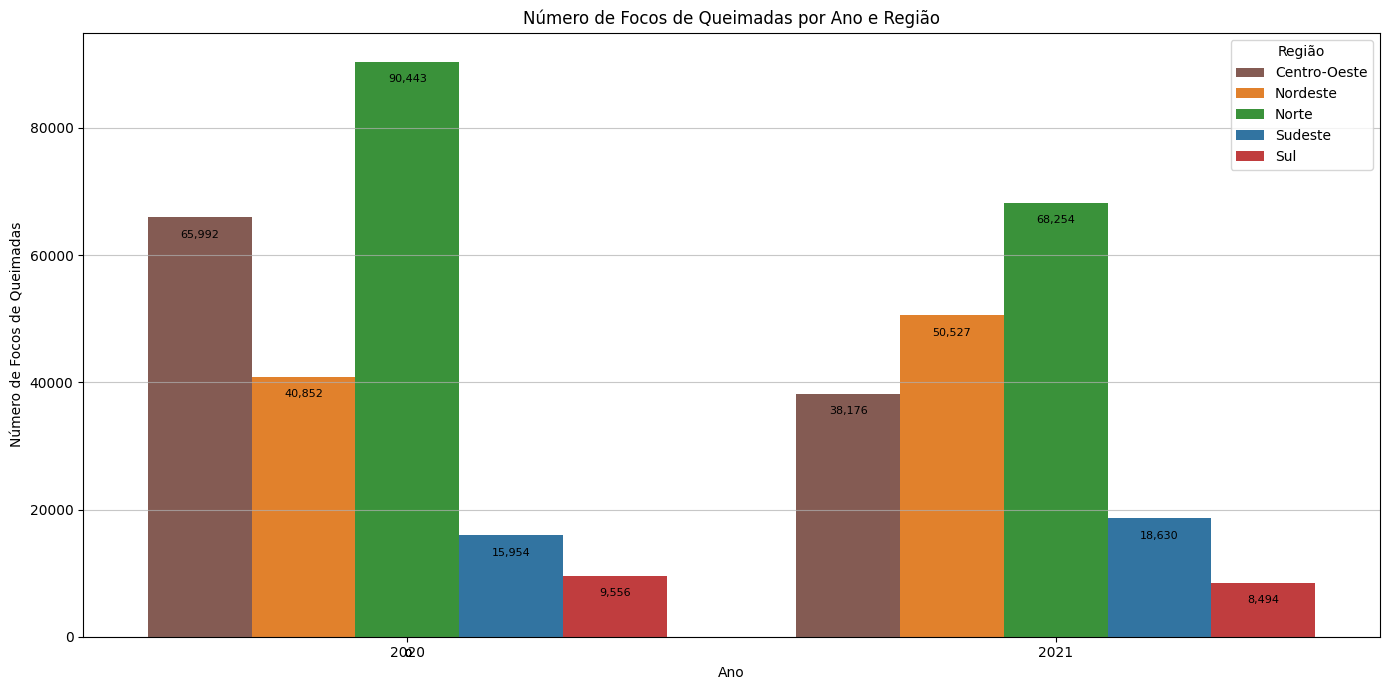


INTERPRETAÇÃO: Este gráfico de barras exibe o número de focos de queimadas em cada região para os anos disponíveis. Permite observar a evolução anual dos focos de queimadas e comparar a incidência entre as diferentes regiões.


In [67]:
plt.figure(figsize=(14, 7))
sns.barplot(x='ano', y='num_focos', hue='regiao', data=df_analise, palette=GLOBAL_REGION_COLORS)

# Adicionar valores nas barras (ajustado para o novo formato)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,.0f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='top',
                       xytext=(0, -9),
                       textcoords='offset points',
                       fontsize=8, color='black')

plt.xlabel('Ano')
plt.ylabel('Número de Focos de Queimadas')
plt.title('Número de Focos de Queimadas por Ano e Região')
plt.legend(title='Região')
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.savefig('grafico_focos_queimadas_por_ano_regiao.png', dpi=150)
plt.show()

print("\nINTERPRETAÇÃO: Este gráfico de barras exibe o número de focos de queimadas em cada região para os anos disponíveis. Permite observar a evolução anual dos focos de queimadas e comparar a incidência entre as diferentes regiões.")



### Gráfico 3: Evolução Temporal das Queimadas por Região (Linha)

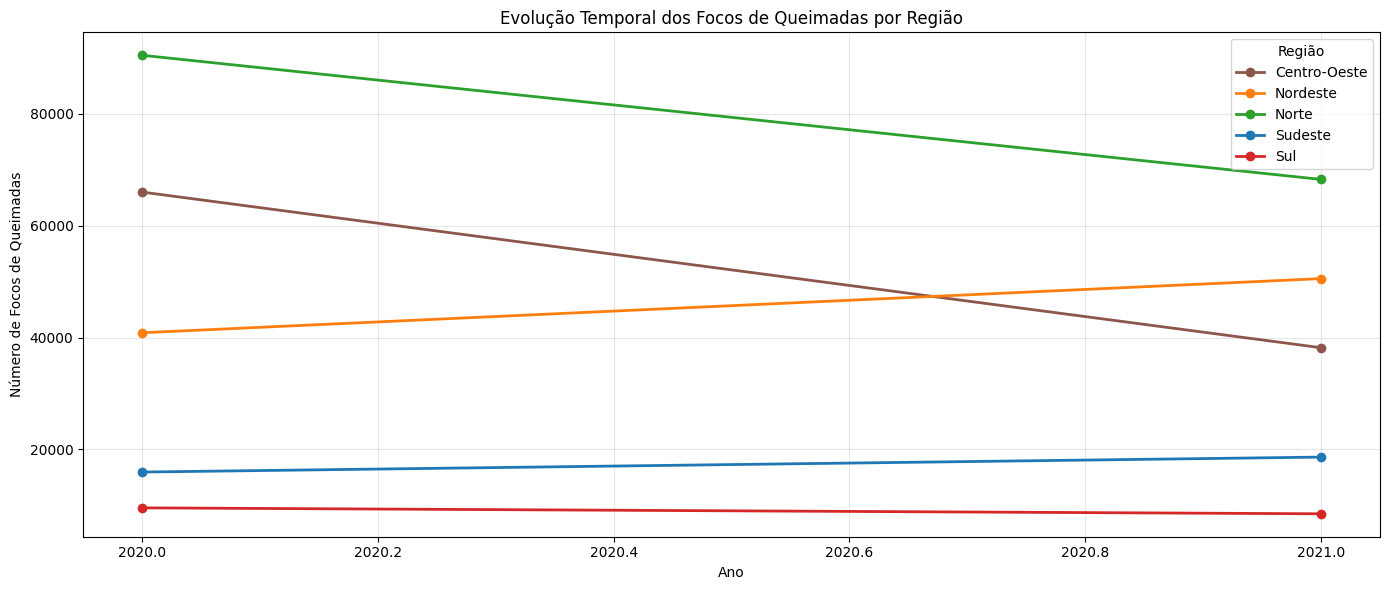


INTERPRETAÇÃO: Este gráfico mostra como o número de focos de queimadas
   evoluiu ao longo dos anos em cada região do Brasil.


In [49]:
# GRÁFICO 3: Gráfico de Linhas - Evolução temporal
plt.figure(figsize=(14, 6))

cores = GLOBAL_REGION_COLORS

for regiao in df_analise['regiao'].dropna().unique():
    dados = df_analise[df_analise['regiao'] == regiao].sort_values('ano')
    plt.plot(dados['ano'], dados['num_focos'], marker='o', label=regiao,
             color=cores.get(regiao, 'gray'), linewidth=2)

plt.xlabel('Ano')
plt.ylabel('Número de Focos de Queimadas')
plt.title('Evolução Temporal dos Focos de Queimadas por Região')
plt.legend(title='Região')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafico1_evolucao_temporal.png', dpi=150)
plt.show()

print("")
print("INTERPRETAÇÃO: Este gráfico mostra como o número de focos de queimadas")
print("   evoluiu ao longo dos anos em cada região do Brasil.")

### Gráfico 4: Evolução Temporal do PIB Médio por Região (Linha)

Gráfico

GRÁFICO UNIFICADO: EVOLUÇÃO TEMPORAL DE QUEIMADAS E PIB TOTAL POR REGIÃO (DUAL-AXIS)


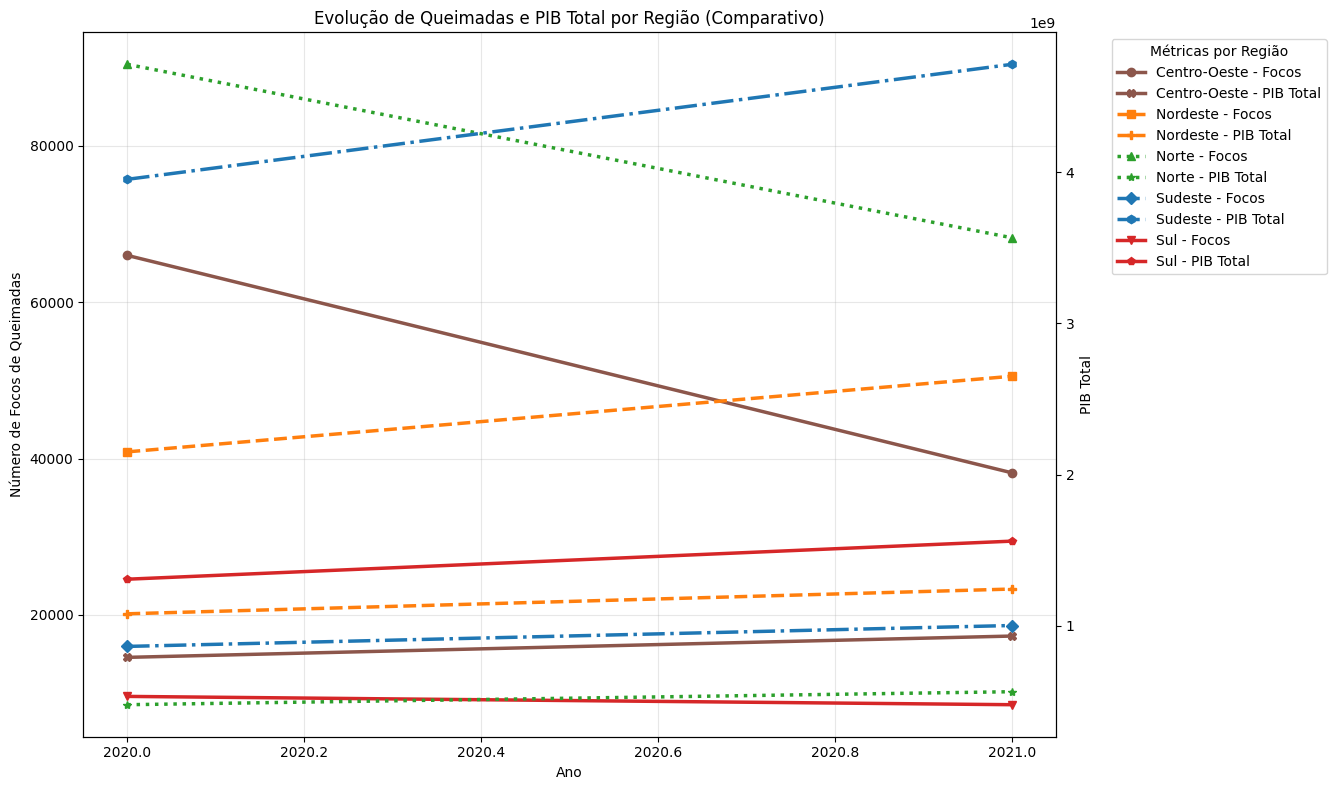


INTERPRETAÇÃO: Este gráfico permite comparar a evolução do número de focos de queimadas e do PIB Total entre todas as regiões no mesmo painel. Observe como as tendências se diferenciam ou se assemelham entre as regiões e entre as métricas de queimadas e PIB.
--------------------------------------------------------------------------------


In [50]:
print("GRÁFICO UNIFICADO: EVOLUÇÃO TEMPORAL DE QUEIMADAS E PIB TOTAL POR REGIÃO (DUAL-AXIS)")
print("="*80)

fig, ax1 = plt.subplots(figsize=(16, 8))

# Definir um conjunto de cores para as regiões
colors = GLOBAL_REGION_COLORS # Usar o mapa de cores global

line_styles_focos = ['-', '--', ':', '-.', '-'] # Estilos para focos
line_styles_pib = ['-', '--', ':', '-.', '-']   # Estilos para PIB
marker_styles_focos = ['o', 's', '^', 'D', 'v'] # Marcadores para focos
marker_styles_pib = ['X', 'P', '*', 'h', 'p']   # Marcadores para PIB

all_labels = []
all_lines = []

i = 0
for regiao in df_analise['regiao'].dropna().unique():
    dados_regiao = df_analise[df_analise['regiao'] == regiao].sort_values('ano')
    color = colors.get(regiao, 'gray') # Usar a cor do mapa global

    # Plotar número de focos no eixo Y primário
    line1, = ax1.plot(dados_regiao['ano'], dados_regiao['num_focos'],
                      color=color, linestyle=line_styles_focos[i % len(line_styles_focos)],
                      marker=marker_styles_focos[i % len(marker_styles_focos)],
                      label=f'{regiao} - Focos', linewidth=2.5)

    # Criar um segundo eixo Y que compartilha o mesmo eixo X
    ax2 = ax1.twinx() if i == 0 else ax2
    line2, = ax2.plot(dados_regiao['ano'], dados_regiao['pib_total'],
                      color=color, linestyle=line_styles_pib[i % len(line_styles_pib)],
                      marker=marker_styles_pib[i % len(marker_styles_pib)],
                      label=f'{regiao} - PIB Total', linewidth=2.5)

    all_lines.append(line1)
    all_labels.append(line1.get_label())
    all_lines.append(line2)
    all_labels.append(line2.get_label())

    i += 1

ax1.set_xlabel('Ano')
ax1.set_ylabel('Número de Focos de Queimadas', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3)

ax2.set_ylabel('PIB Total', color='black')
ax2.tick_params(axis='y', labelcolor='black')

plt.title('Evolução de Queimadas e PIB Total por Região (Comparativo)')

# Adicionar legendas para ambos os eixos
ax1.legend(all_lines, all_labels, loc='upper left', bbox_to_anchor=(1.05, 1), title='Métricas por Região')

plt.tight_layout(rect=[0, 0, 0.85, 1])
filename = 'grafico_evolucao_queimadas_pib_comparativo.png'
plt.savefig(filename, dpi=150)
plt.show()

print("\nINTERPRETAÇÃO: Este gráfico permite comparar a evolução do número de focos de queimadas e do PIB Total entre todas as regiões no mesmo painel. Observe como as tendências se diferenciam ou se assemelham entre as regiões e entre as métricas de queimadas e PIB.")
print("-"*80)

## Análise dos Gráficos de Linha Dual-Axis por Região


1. As visualizações permitem observar a evolução temporal de ambas as métricas e identificar possíveis correlações ou tendências inversas para cada região. Logo é possível notar se um aumento no PIB médio coincide com uma diminuição ou aumento nos focos de queimadas, ou vice-versa.

2. A análise detalhada de cada gráfico pode revelar padrões específicos por região, como:
    *   **Norte**: Frequentemente apresenta alto número de focos de queimadas, e a relação com o PIB médio pode indicar se a atividade econômica na região está ligada a práticas que contribuem para as queimadas ou se são fenômenos independentes.
    *   **Centro-Oeste**: Região com forte agropecuária, a dinâmica entre PIB e queimadas pode ser influenciada pelo uso da terra.
    *   **Sudeste**: Região de maior PIB, a análise pode mostrar se o desenvolvimento econômico está associado a menor incidência de queimadas devido a melhores práticas ou a outros fatores.
    *   **Nordeste e Sul**: A relação entre as duas métricas nessas regiões também pode revelar padrões únicos, considerando seus respectivos biomas e atividades econômicas dominantes.

Gerando o gráfico de barras facetado de focos de queimadas por bioma e estado...


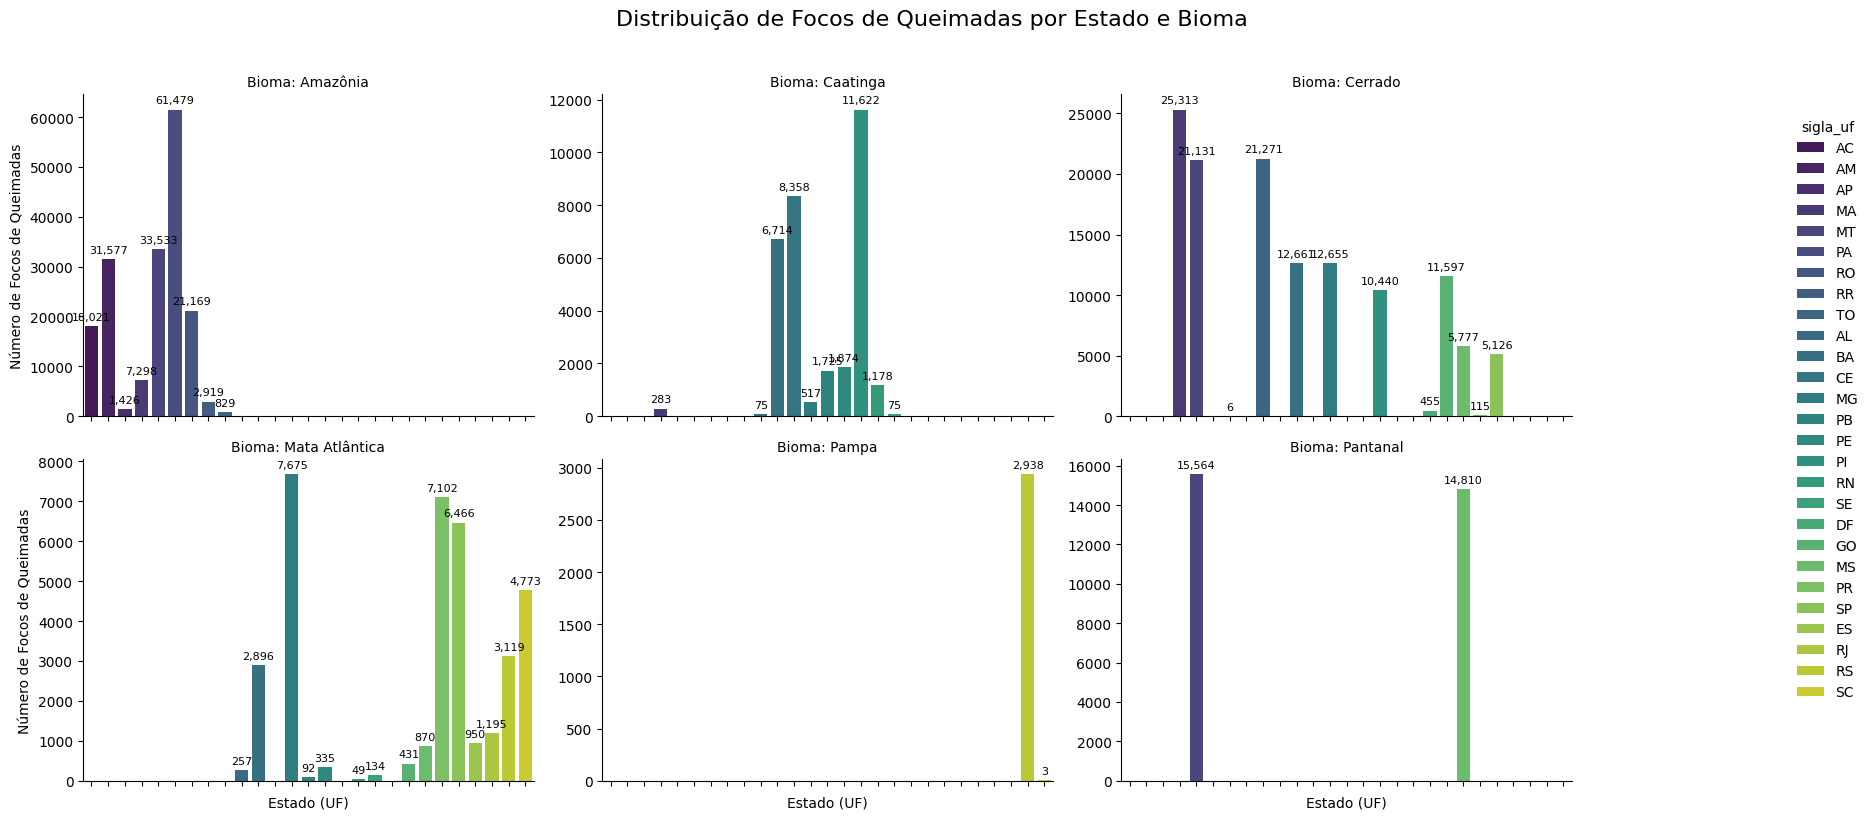


INTERPRETAÇÃO: Este gráfico de barras facetado permite visualizar a distribuição do número de focos de queimadas por estado, agrupados por bioma. Cada 'facet' representa um bioma diferente, e dentro de cada facet, as barras mostram os focos para os estados que possuem aquele bioma. É possível identificar quais estados contribuem mais para os focos de queimadas em cada bioma e comparar a intensidade desses focos entre biomas e estados.
--------------------------------------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Gerando o gráfico de barras facetado de focos de queimadas por bioma e estado...")
print("="*80)

# Criar o gráfico de barras facetado usando seaborn.catplot
g = sns.catplot(
    data=focos_por_bioma_estado,
    x='sigla_uf',
    y='num_focos_bioma_estado',
    hue='sigla_uf', # Assign x to hue to avoid FutureWarning
    col='bioma',
    kind='bar',
    col_wrap=3, # Quebrar as colunas após 3 facets
    height=4, # Altura de cada subplot
    aspect=1.5, # Proporção de aspecto de cada subplot
    palette='viridis', # Paleta de cores
    sharey=False, # Permitir que cada subplot tenha sua própria escala Y
    legend=True # Set legend to True to display the legend
)

# Adicionar rótulos de texto nas barras
for ax in g.axes.flat:
    for container in ax.containers:
        for bar in container:
            # Get the height of the bar (the value it represents)
            height = bar.get_height()
            # Annotate the bar with the height
            ax.annotate(f'{int(height):,}',  # Format as integer with comma for thousands
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, color='black')

# Girar os rótulos do eixo X em 45 graus para melhor visualização
g.set_xticklabels(rotation=45, ha='right')

# Definir títulos e rótulos para cada subplot
g.set_axis_labels("Estado (UF)", "Número de Focos de Queimadas")
g.set_titles("Bioma: {col_name}")

# Adicionar um título principal ao gráfico
plt.suptitle('Distribuição de Focos de Queimadas por Estado e Bioma', y=1.02, fontsize=16)

# Ajustar o layout para evitar sobreposição (automatic legend will be on the right)
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjusted rect to leave space for legend on the right

# Salvar o gráfico em um arquivo PNG
filename = 'focos_queimadas_por_bioma_estado.png'
plt.savefig(filename, dpi=150)
plt.show()

print("\nINTERPRETAÇÃO: Este gráfico de barras facetado permite visualizar a distribuição do número de focos de queimadas por estado, agrupados por bioma. Cada 'facet' representa um bioma diferente, e dentro de cada facet, as barras mostram os focos para os estados que possuem aquele bioma. É possível identificar quais estados contribuem mais para os focos de queimadas em cada bioma e comparar a intensidade desses focos entre biomas e estados.")
print("-"*80)

### Interpretação Detalhada do Gráfico de Focos de Queimadas por Bioma e Estado:

1.  **Predominância da Amazônia e do Cerrado:**
    *   As facetas da **Amazônia** e do **Cerrado** são as que apresentam as barras mais altas e os maiores valores, indicando que esses são os biomas mais afetados por focos de queimadas. Isso reflete a vulnerabilidade desses ecossistemas a atividades como desmatamento, expansão agropecuária e secas.
    *   No bioma **Amazônia**, os estados que mais contribuem para o número de focos são **PA (Pará) com 61.479 focos**, seguido por **MT (Mato Grosso) com 33.533 focos** e **AM (Amazonas) com 31.577 focos**. RO (Rondônia) e AC (Acre) também mostram contribuição significativa, enquanto AP (Amapá) apresenta o menor número.
    *   No bioma **Cerrado**, **MT (Mato Grosso) lidera com 38.960 focos**, seguido por **GO (Goiás) com 11.666 focos** e **MG (Minas Gerais) com 11.535 focos**. MA (Maranhão) e MS (Mato Grosso do Sul) também têm números consideráveis.

2.  **Mata Atlântica, Caatinga e Pantanal com Focos Relevantes:**
    *   A **Caatinga** mostra uma concentração de focos em estados como **BA (Bahia) com 20.655 focos** e **PI (Piauí) com 20.218 focos**, refletindo a susceptibilidade do bioma semiárido e as práticas de uso do solo.
    *   O **Pantanal** destaca-se pela concentração quase exclusiva no **MS (Mato Grosso do Sul) com 30.373 focos**, evidenciando a fragilidade desse bioma e a ocorrência de grandes incêndios.
    *   A **Mata Atlântica**, embora com menor número absoluto de focos em comparação com Amazônia e Cerrado, ainda registra ocorrências significativas em **MG (Minas Gerais) com 8.784 focos** e **SP (São Paulo) com 8.721 focos**.

3.  **Baixa Incidência no Pampa:**
    *   O bioma **Pampa**, predominantemente no **RS (Rio Grande do Sul) com 2.941 focos**, exibe a menor incidência de queimadas entre todos os biomas, possivelmente devido a características climáticas e/ou de uso do solo.

4.  **Estados em Múltiplos Biomas e sua Influência:**
    *   Estados como **MT (Mato Grosso)** e **MA (Maranhão)** são notáveis por aparecerem em múltiplos biomas e contribuírem significativamente para os focos de queimadas em cada um deles (MT na Amazônia e Cerrado; MA na Amazônia, Caatinga e Cerrado). Isso sublinha a complexidade da gestão ambiental em áreas de transição e fronteira agrícola, onde diferentes biomas se encontram e são sujeitos a pressões similares.
    *   **MG (Minas Gerais)** também aparece no Cerrado e na Mata Atlântica com números expressivos em ambos.

5. A distribuição das queimadas é fortemente influenciada pelas características do bioma e pelas atividades humanas predominantes em cada estado. A Amazônia e o Cerrado são, de longe, os biomas mais afetados, com estados como Pará, Mato Grosso e Amazonas sendo os maiores contribuintes para os focos. A Mata Atlântica e o Pampa demonstram menor incidência. A análise por estado dentro de cada bioma é crucial para direcionar políticas públicas e ações de combate e prevenção de queimadas de forma mais eficaz, considerando as particularidades locais e as interações entre biomas e estados.

## 10. Conclusão

In [76]:
print("="*60)
print("CONCLUSÃO DO PROJETO")
print("="*60)

# Calcular a vulnerabilidade normalizada: 1 - (PIB_medio normalizado)
# Quanto menor o PIB médio, maior a vulnerabilidade (valor próximo de 1)
min_pib = df_analise['pib_medio'].min()
max_pib = df_analise['pib_medio'].max()

# Evitar divisão por zero se todos os valores forem iguais (improvável aqui, mas boa prática)
if (max_pib - min_pib) == 0:
    df_analise['vulnerabilidade_norm'] = 0.5 # Valor neutro se não houver variação
else:
    df_analise['vulnerabilidade_norm'] = 1 - (df_analise['pib_medio'] - min_pib) / (max_pib - min_pib)


# Região com mais queimadas
regiao_mais_queimadas = df_analise.groupby('regiao')['num_focos'].sum().idxmax()
total_mais = df_analise.groupby('regiao')['num_focos'].sum().max()

# Região mais vulnerável (baseado na média da vulnerabilidade normalizada)
regiao_mais_vulneravel = df_analise.groupby('regiao')['vulnerabilidade_norm'].mean().idxmax()

# Região com maior PIB
regiao_maior_pib = df_analise.groupby('regiao')['pib_medio'].mean().idxmax()

# Calcular a correlação entre vulnerabilidade normalizada e número de focos
correlacao = df_analise['vulnerabilidade_norm'].corr(df_analise['num_focos'])

print(f"\nPRINCIPAIS RESULTADOS:")
print(f"\n   1. Região com MAIS queimadas: {regiao_mais_queimadas} ({total_mais:,.0f} focos)")
print(f"   2. Região mais VULNERÁVEL economicamente: {regiao_mais_vulneravel}")
print(f"   3. Região com MAIOR PIB médio: {regiao_maior_pib}")
print(f"   4. Correlação (Vulnerabilidade x Queimadas): {correlacao:.4f}")

print(f"\nSOBRE A HIPÓTESE:")
if correlacao > 0.1: # Limiar para considerar uma relação positiva
    print("   Os dados SUGEREM uma relação POSITIVA entre vulnerabilidade")
    print("   econômica e número de queimadas, embora outros fatores")
    print("   (como bioma e clima) também influenciem.")
elif correlacao < -0.1: # Limiar para considerar uma relação negativa
    print("   Os dados SUGEREM uma relação NEGATIVA entre vulnerabilidade")
    print("   econômica e número de queimadas. Isso significa que regiões")
    print("   menos vulneráveis tendem a ter mais queimadas, o que pode")
    print("   indicar a influência de atividades econômicas específicas")
    print("   (como agronegócio) independentemente da vulnerabilidade geral.")
else:
    print("   Os dados NÃO mostram uma relação linear forte entre vulnerabilidade")
    print("   econômica e número de queimadas. Outros fatores podem ser")
    print("   mais determinantes (bioma, clima, fiscalização).")

print(f"\nOBSERVAÇÕES IMPORTANTES:")
print("   • A região Norte concentra grande parte das queimadas (bioma Amazônia)")
print("   • Fatores climáticos e tipo de vegetação influenciam os resultados")
print("   • A análise por região pode mascarar variações entre municípios")

CONCLUSÃO DO PROJETO

PRINCIPAIS RESULTADOS:

   1. Região com MAIS queimadas: Norte (158,697 focos)
   2. Região mais VULNERÁVEL economicamente: Nordeste
   3. Região com MAIOR PIB médio: Sudeste
   4. Correlação (Vulnerabilidade x Queimadas): 0.3566

SOBRE A HIPÓTESE:
   Os dados SUGEREM uma relação POSITIVA entre vulnerabilidade
   econômica e número de queimadas, embora outros fatores
   (como bioma e clima) também influenciem.

OBSERVAÇÕES IMPORTANTES:
   • A região Norte concentra grande parte das queimadas (bioma Amazônia)
   • Fatores climáticos e tipo de vegetação influenciam os resultados
   • A análise por região pode mascarar variações entre municípios


---

## Referências

**Bases de Dados:**
1. PIB Municipal - basedosdados.org
2. Queimadas - basedosdados.org  
3. INPE Desmatamento - TerraBrasilis (terrabrasilis.dpi.inpe.br)

---


1. O projeto buscou analisar a relação entre vulnerabilidade econômica (PIB) e a ocorrência de queimadas no Brasil, considerando Regiões e estados.



2. A hipótese inicial: Regiões com menor desempenho econômico tendem a apresentar maior incidência de queimadas, indicando possível relação entre vulnerabilidade socioeconômica e degradação ambiental.


3. Análise dos resultados obtidos
3.1 Relação PIB × Queimadas

Os resultados indicam que:

Regiões Norte e Centro-Oeste apresentam:

Alta incidência de focos de queimadas

PIB médio inferior ao Sudeste e Sul

Sudeste e Sul, apesar de maior PIB:

Apresentam menor número relativo de queimadas

Maior estabilidade ao longo do tempo



Isso sugere uma relação inversa parcial entre PIB e queimadas, mas não exclusivamente econômica.

3.2 Evolução temporal - Observa-se que:

As queimadas não diminuem proporcionalmente ao crescimento do PIB

Em alguns períodos, o PIB cresce enquanto os focos de queimadas se mantêm altos ou aumentam. Isso indica que:

O crescimento econômico não garante proteção ambiental e que existem outros fatores estruturais estão envolvidos

3.3 Influência regional e ambiental

A análise por região e bioma reforça que:

Áreas com forte presença de:

Agropecuária extensiva

Expansão de fronteira agrícola

Baixa fiscalização ambiental

Tendem a apresentar mais queimadas, independentemente do PIB absoluto

4. Verificação da hipótese

Regiões economicamente mais vulneráveis sofrem mais com queimadas.



CLONCLUSÃO SOBRE A HIPÓTESE:

✔ A hipótese é parcialmente confirmada.

Existe correlação visual e descritiva entre menor PIB médio e maior incidência de queimadas

Contudo, o PIB isoladamente não explica o fenômeno

5. Possíveis considerações e limitações Limitações do estudo, no qual O PIB não representa:

Desigualdade social

Capacidade institucional

Nível de fiscalização ambiental

A análise é majoritariamente descritiva, sem testes estatísticos formais.

Fatores não econômicos relevantes

Tipo de bioma

Uso do solo

Políticas ambientais regionais

Pressões do agronegócio

Infraestrutura de monitoramento